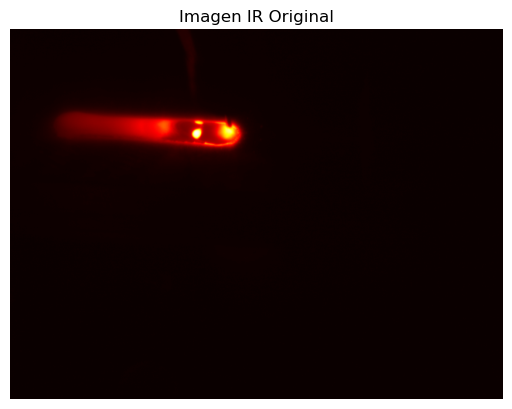

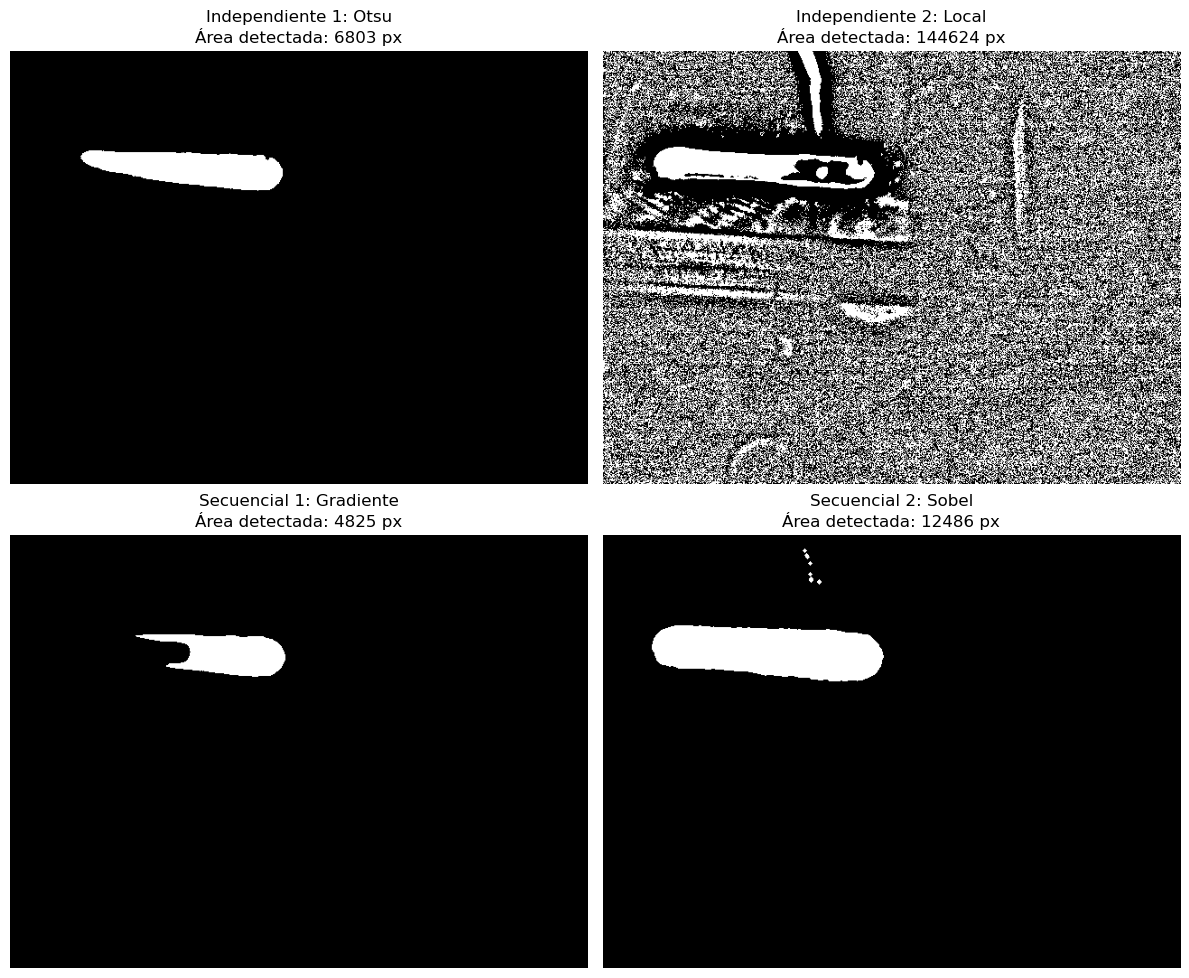

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, morphology
from scipy import ndimage as ndi

# 1. Cargar la imagen
nombre_archivo = '1734589458844.tif'
imagen_original = cv2.imread(nombre_archivo, cv2.IMREAD_UNCHANGED)
if imagen_original is None:
    raise ValueError("No se pudo cargar la imagen. Verifique la ruta.")

# =========================================================
# TÉCNICAS INDEPENDIENTES (Basadas en un solo criterio)
# =========================================================

# Independiente 1: Umbralización Global (Otsu)
umbral_otsu = filters.threshold_otsu(imagen_original)
roi_indep_1 = imagen_original > umbral_otsu

# Independiente 2: Umbralización Local (Adaptativa)
# Ideal si una parte del cordón brilla más que otra
umbral_local = filters.threshold_local(imagen_original, block_size=35)
roi_indep_2 = imagen_original > umbral_local


# =========================================================
# TÉCNICAS SECUENCIALES (Flujos de varios pasos)
# =========================================================

# Secuencial 1: Filtro Mediana -> Gradiente -> Cierre -> Relleno
suave_1 = filters.median(imagen_original, morphology.disk(3))
gradiente = morphology.dilation(suave_1, morphology.disk(3)) - morphology.erosion(suave_1, morphology.disk(3))
roi_sec_1 = gradiente > filters.threshold_isodata(gradiente)
roi_sec_1 = morphology.closing(roi_sec_1, morphology.disk(10))
roi_sec_1 = ndi.binary_fill_holes(roi_sec_1)

# Secuencial 2: Filtro Gaussiano -> Sobel -> Apertura -> Relleno
# El filtro de Sobel destaca bordes verticales/horizontales
suave_2 = filters.gaussian(imagen_original, sigma=1)
sobel = filters.sobel(suave_2)
roi_sec_2 = sobel > filters.threshold_li(sobel) # Umbral de Li para bordes
roi_sec_2 = morphology.opening(roi_sec_2, morphology.disk(2)) # Quita ruido
roi_sec_2 = ndi.binary_fill_holes(roi_sec_2)

# =========================================================
# COMPARATIVA Y VISUALIZACIÓN
# =========================================================
plt.imshow(imagen_original, cmap='hot')
plt.title("Imagen IR Original")
plt.axis('off')
plt.show()

tecnicas = [roi_indep_1, roi_indep_2, roi_sec_1, roi_sec_2]
titulos = ['Independiente 1: Otsu', 'Independiente 2: Local', 'Secuencial 1: Gradiente', 'Secuencial 2: Sobel']

fig, ejes = plt.subplots(2, 2, figsize=(12, 10))
ejes = ejes.ravel()

for i in range(4):
    area = np.sum(tecnicas[i])
    ejes[i].imshow(tecnicas[i], cmap='gray')
    ejes[i].set_title(f'{titulos[i]}\nÁrea detectada: {area} px')
    ejes[i].axis('off')
    #print(f"{titulos[i]} - Área detectada: {area} px")

plt.tight_layout()
plt.show()


# Desarrollo realizado
Se implementaron cuatro algoritmos para la segmentación del cordón de soldadura en imágenes infrarrojas.
El desarrollo se dividió en dos enfoques:

### Independientes: 
Basados en criterios de umbralización directa (Global y Local).
### Secuenciales: 
Flujos de procesamiento que integran filtros espaciales (Mediana y Gaussiano) para pre-procesamiento, detección de bordes (Sobel y Gradiente) y morfología matemática (Clausura, Apertura y Relleno de huecos) para el post-procesamiento.

# Análisis y Conclusiones: Selección del Área de Interés (ROI) en Imágenes IR
## Comparativa de Técnicas Independientes

### Umbralización Global (Otsu):
Se identificó como una técnica eficiente cuando existe un contraste térmico marcado entre el cordón de soldadura y la placa base. Sin embargo, su limitación principal es la falta de detalle en las zonas de transición térmica.

### Umbralización Local (Adaptativa):
A diferencia de la global, esta técnica permitió resaltar texturas finas del cordón, pero introdujo "ruido" en áreas donde la temperatura es uniforme, lo que dificulta la obtención de un área de interés limpia sin procesos adicionales.

## Comparativa de Técnicas Secuenciales

### Flujo de Gradiente Morfológico:
Esta técnica demostró ser la más robusta para imágenes de soldadura. Al combinar el filtrado de mediana con el gradiente, se logró resaltar el relieve físico del cordón. El uso posterior de clausura morfológica (closing) y relleno de huecos permitió consolidar una máscara sólida que representa fielmente la geometría de la unión.

### Flujo de Sobel y Filtro Gaussiano:
Este método generó bordes más suavizados y continuos. Es ideal para detectar la silueta general, aunque tiende a subestimar el área real si los bordes del cordón son muy difusos debido a la conducción térmica en el metal.

## Conclusión General
El análisis cuantitativo mediante el cálculo de áreas demuestra que las técnicas secuenciales ofrecen un control superior sobre la segmentación. Mientras que las técnicas independientes son rápidas, las secuenciales como el Gradiente Morfológico, permiten filtrar artefactos térmicos no deseados y aislar exclusivamente la morfología del cordón de soldadura, garantizando un ROI más preciso para inspecciones de calidad.